In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

In [4]:
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [5]:
df = pd.read_csv('Cust_dataset.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 7043 rows × 21 columns


In [6]:
print('First 5 Rows')
df.head()

First 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print('Last 5 Rows')
df.tail()

Last 5 Rows


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
print('Column Names & Data Types')
print(df.dtypes)

Column Names & Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
print('Dataset Info')
df.info()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [10]:
print('Unique Values Per Column')
df.nunique()

Unique Values Per Column


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
print(' Target Variable: Churn')
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.2f}%')

 Target Variable: Churn
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


In [12]:
print(' Missing Values Per Column ')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No NaN values found!')
print(f'\nTotal missing: {df.isnull().sum().sum()}')

 Missing Values Per Column 
No NaN values found!

Total missing: 0


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Rows with NaN in TotalCharges after conversion:')
print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Rows with NaN in TotalCharges after conversion:
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           NaN
3826  3213-VVOLG       0           25.35           NaN
4380  2520-SGTTA       0           20.00           NaN
5218  2923-ARZLG       0           19.70           NaN
6670  4075-WKNIU       0           73.35           NaN
6754  2775-SEFEE       0           61.90           NaN


In [14]:
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

print(f'Missing values after fix: {df["TotalCharges"].isnull().sum()}')

Missing values after fix: 0


In [15]:
print(f'Duplicate rows: {df.duplicated().sum()}')

df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Duplicate rows: 0
Shape after removing duplicates: (7043, 21)


In [16]:
df.drop(columns=['customerID'], inplace=True)
print('customerID column dropped.')

customerID column dropped.


In [17]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print('SeniorCitizen converted to Yes/No')

SeniorCitizen converted to Yes/No


In [18]:
df_clean = df.copy()
print('Cleaned dataset ready!')
print(f'Shape: {df_clean.shape}')
df_clean.head()

Cleaned dataset ready!
Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
print(' Basic Statistics ')
df_clean.describe()

 Basic Statistics 


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.798992
std,24.559481,30.090047,2266.730170
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [20]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'InternetService', 'PaymentMethod']:
    print(f'\n{col}:')
    print(df_clean[col].value_counts())

Categorical columns (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

SeniorCitizen:
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, 

In [21]:
print('Average values by Churn')
df_clean.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)

Average values by Churn


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2550.0
Yes,17.98,74.44,1531.8


In [22]:
print(' Correlation Matrix ')
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
corr = df_clean[num_cols].corr()
print(corr)

 Correlation Matrix 
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826164
MonthlyCharges  0.247900        1.000000      0.651182
TotalCharges    0.826164        0.651182      1.000000


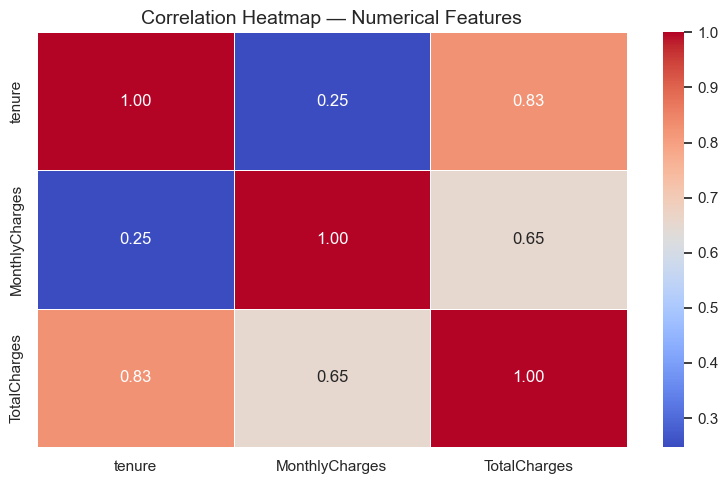

In [23]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

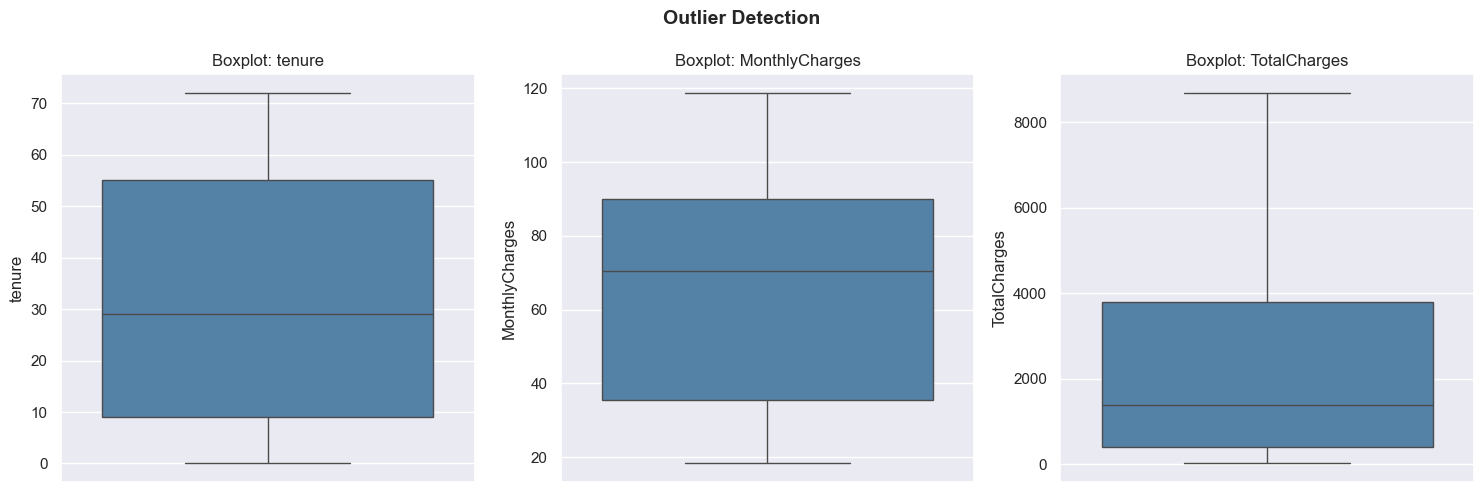

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df_clean[col], ax=ax, color='steelblue')
    ax.set_title(f'Boxplot: {col}')

plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

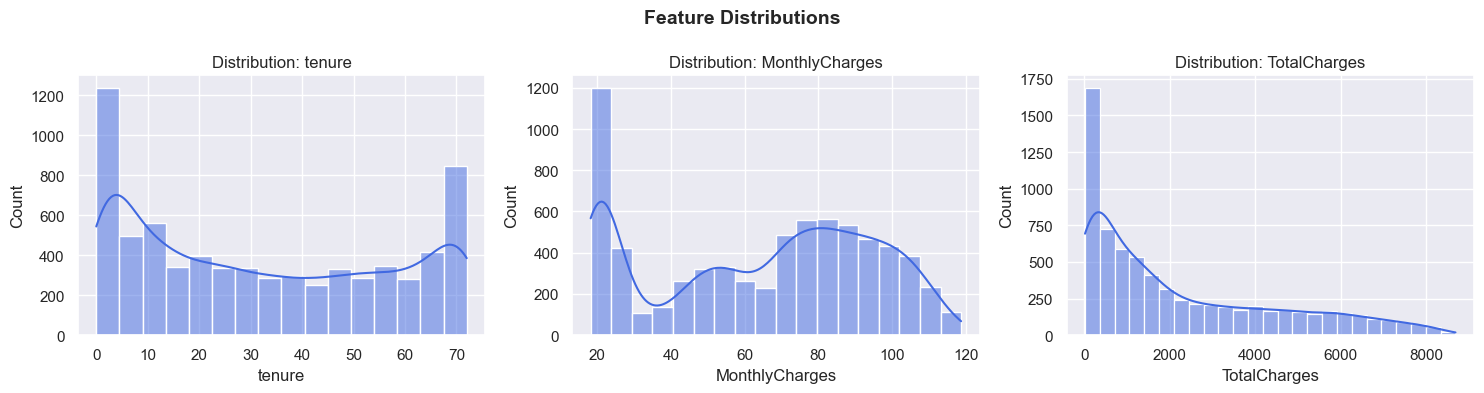

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='royalblue')
    ax.set_title(f'Distribution: {col}')

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

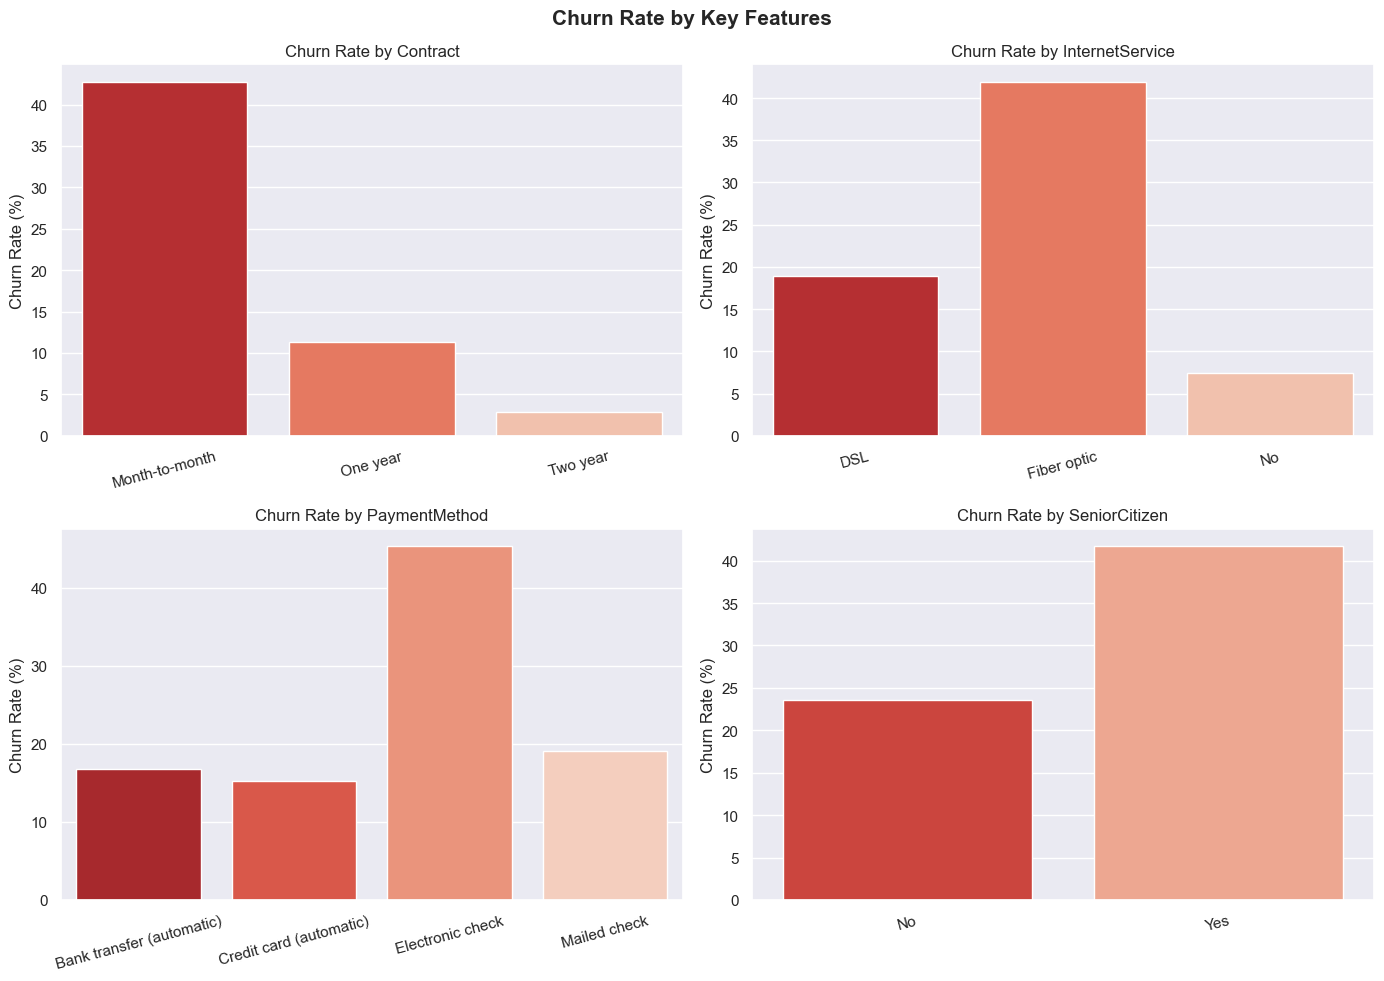

In [26]:
churn_features = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(churn_features):
    churn_rate = df_clean.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    sns.barplot(data=churn_rate, x=col, y='Churn Rate (%)', ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Churn Rate by Key Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

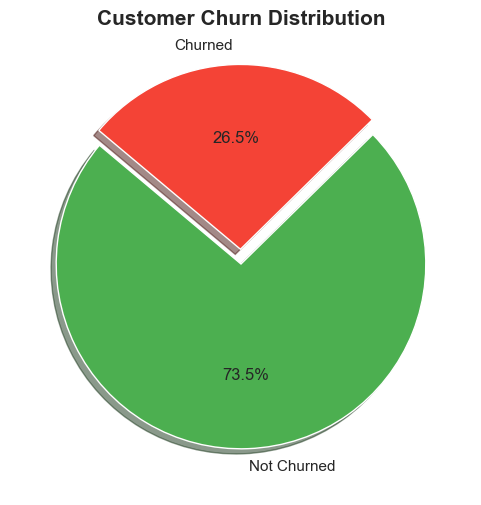

 Insight: ~26% of customers have churned — class imbalance exists.


In [27]:
churn_counts = df_clean['Churn'].value_counts()

plt.figure(figsize=(7, 6))
plt.pie(
    churn_counts,
    labels=['Not Churned', 'Churned'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=140,
    explode=(0, 0.08),
    shadow=True
)
plt.title('Customer Churn Distribution', fontsize=15, fontweight='bold')
plt.show()

print(' Insight: ~26% of customers have churned — class imbalance exists.')

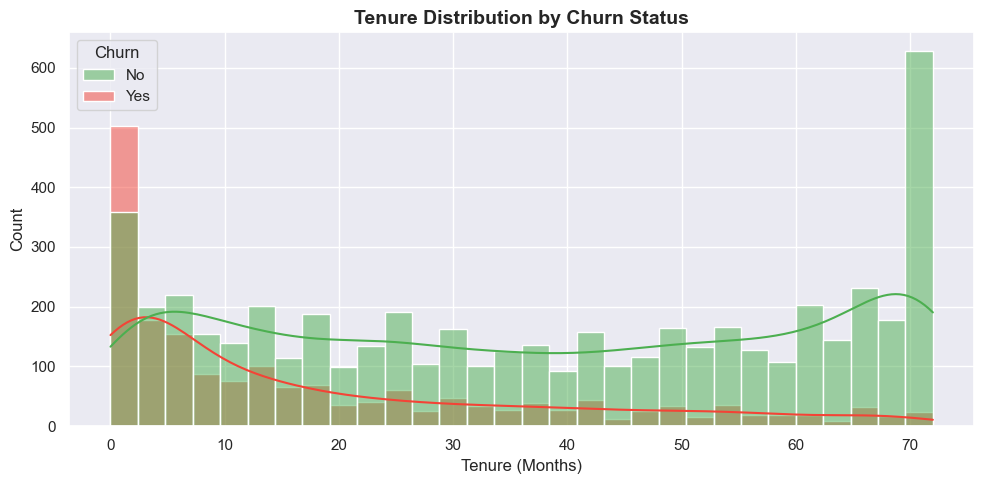

Insight: Churned customers tend to leave early — peak churn in first few months.


In [28]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_clean, x='tenure', hue='Churn',
    bins=30, kde=True, palette={'Yes': '#F44336', 'No': '#4CAF50'}
)
plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Insight: Churned customers tend to leave early — peak churn in first few months.')

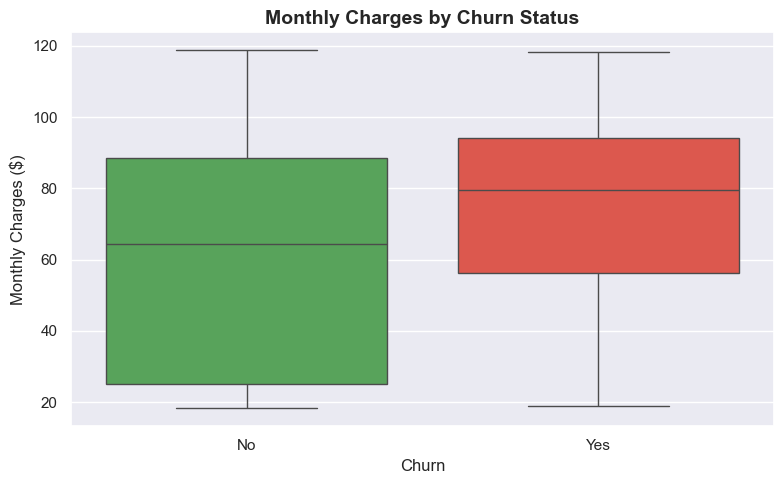

Insight: Churned customers pay higher monthly charges on average.


In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean, x='Churn', y='MonthlyCharges',
    palette={'Yes': '#F44336', 'No': '#4CAF50'}
)
plt.title('Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print('Insight: Churned customers pay higher monthly charges on average.')

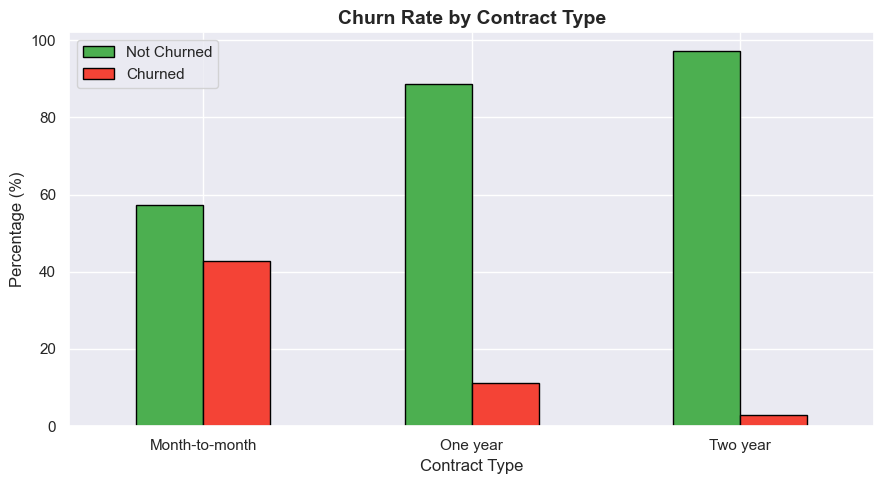

Insight: Month-to-month customers churn at ~43% vs <5% for two-year contracts.


In [30]:
contract_churn = df_clean.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

contract_churn.plot(kind='bar', color=['#4CAF50', '#F44336'], figsize=(9, 5), edgecolor='black')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.show()

print('Insight: Month-to-month customers churn at ~43% vs <5% for two-year contracts.')

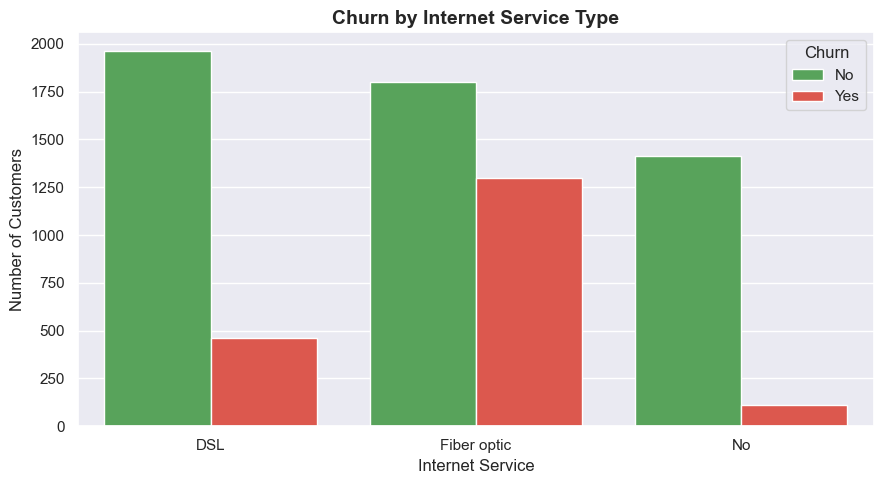

 Insight: Fiber optic users have significantly more churners.


In [31]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_clean, x='InternetService', hue='Churn',
    palette={'Yes': '#F44336', 'No': '#4CAF50'}
)
plt.title('Churn by Internet Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(' Insight: Fiber optic users have significantly more churners.')

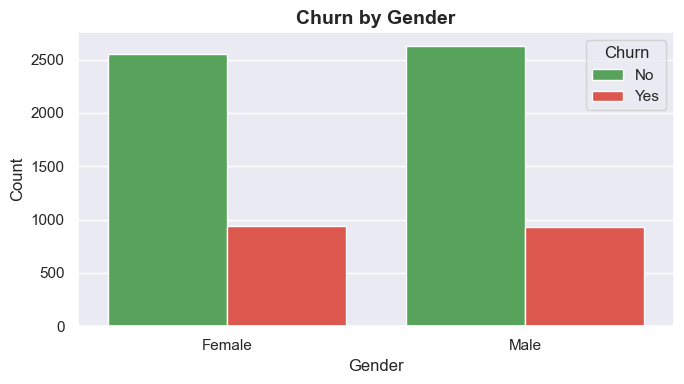

Insight: Gender has minimal impact on churn — nearly equal distribution.


In [32]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df_clean, x='gender', hue='Churn',
    palette={'Yes': '#F44336', 'No': '#4CAF50'}
)
plt.title('Churn by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('Insight: Gender has minimal impact on churn — nearly equal distribution.')

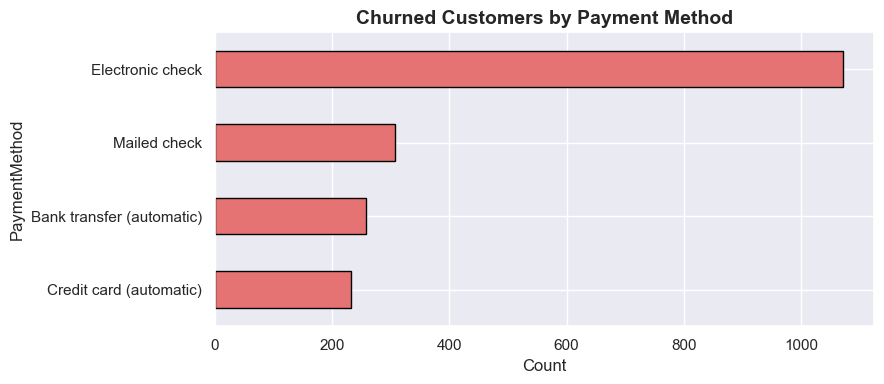

 Insight: Electronic check is the most common payment method among churned customers.


In [33]:
payment_churn = df_clean[df_clean['Churn'] == 'Yes']['PaymentMethod'].value_counts()

plt.figure(figsize=(9, 4))
payment_churn.sort_values().plot(kind='barh', color='#E57373', edgecolor='black')
plt.title('Churned Customers by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print(' Insight: Electronic check is the most common payment method among churned customers.')

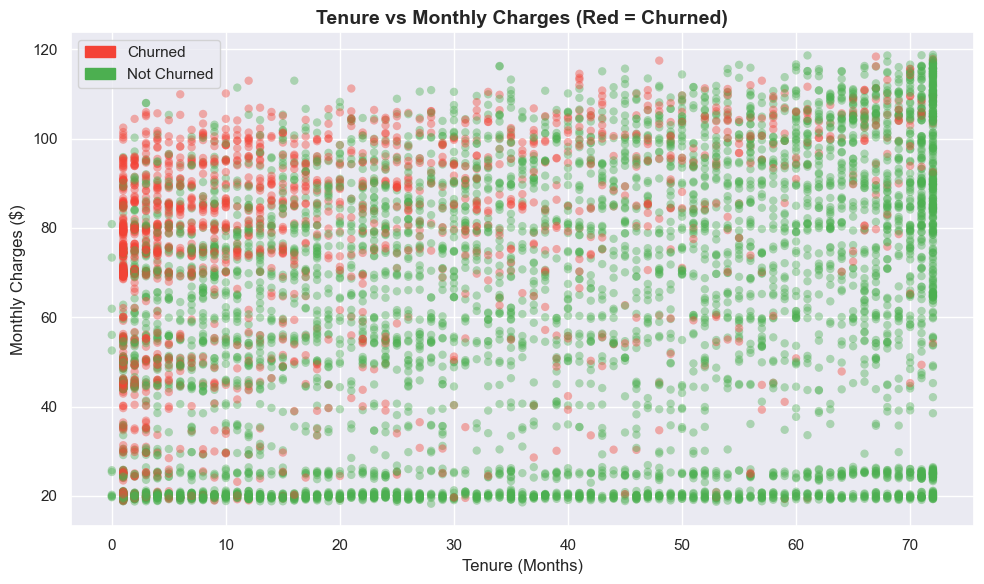

 Insight: Churned customers cluster in low-tenure + high-monthly-charge zone.


In [34]:
plt.figure(figsize=(10, 6))
colors = df_clean['Churn'].map({'Yes': '#F44336', 'No': '#4CAF50'})
plt.scatter(df_clean['tenure'], df_clean['MonthlyCharges'], c=colors, alpha=0.4, edgecolors='none')
plt.title('Tenure vs Monthly Charges (Red = Churned)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#F44336', label='Churned')
green_patch = mpatches.Patch(color='#4CAF50', label='Not Churned')
plt.legend(handles=[red_patch, green_patch])
plt.tight_layout()
plt.show()

print(' Insight: Churned customers cluster in low-tenure + high-monthly-charge zone.')

In [35]:
df_model = df_clean.copy()

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

print('Target variable encoded: Yes=1, No=0')
print(df_model['Churn'].value_counts())

Target variable encoded: Yes=1, No=0
Churn
0    5174
1    1869
Name: count, dtype: int64


In [36]:
le = LabelEncoder()
cat_features = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_features)} categorical columns: {cat_features}')

for col in cat_features:
    df_model[col] = le.fit_transform(df_model[col])

print('\n All categorical columns encoded.')
df_model.head()

Encoding 16 categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

 All categorical columns encoded.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [37]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape: (7043, 19)
Target shape: (7043,)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 5634
Testing samples:  1409


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(' Features scaled using StandardScaler.')

 Features scaled using StandardScaler.


In [40]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print(' Logistic Regression Results ')
print(f'Accuracy: {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'ROC-AUC:  {roc_auc_score(y_test, lr_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Not Churned', 'Churned']))

 Logistic Regression Results 
Accuracy: 79.84%
ROC-AUC:  0.8404

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.84      0.89      0.87      1035
     Churned       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest Results')
print(f'Accuracy: {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'ROC-AUC:  {roc_auc_score(y_test, rf_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Not Churned', 'Churned']))

Random Forest Results
Accuracy: 79.56%
ROC-AUC:  0.8237

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.84      0.90      0.87      1035
     Churned       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



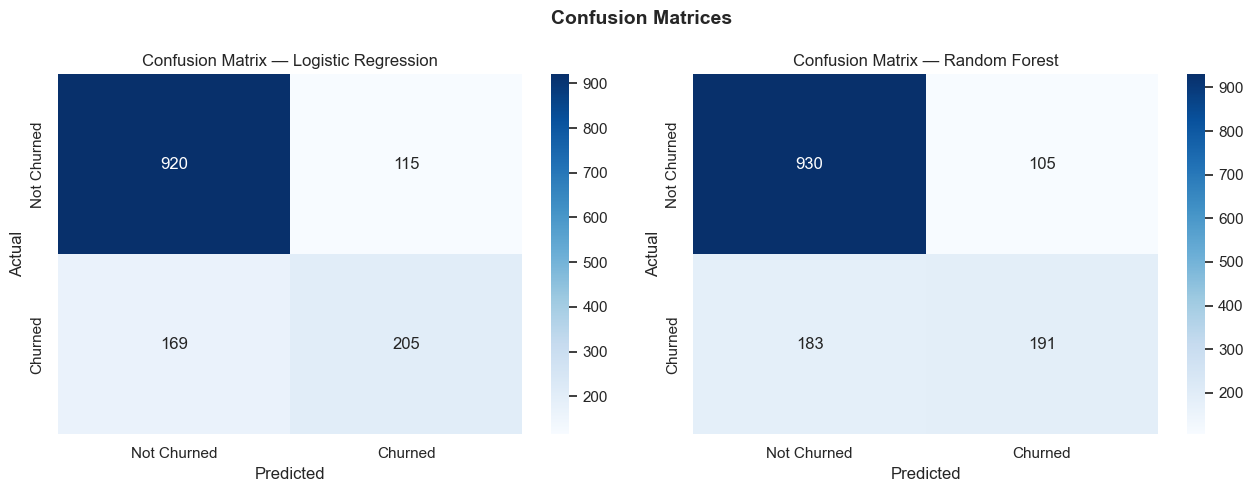

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, rf_pred],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

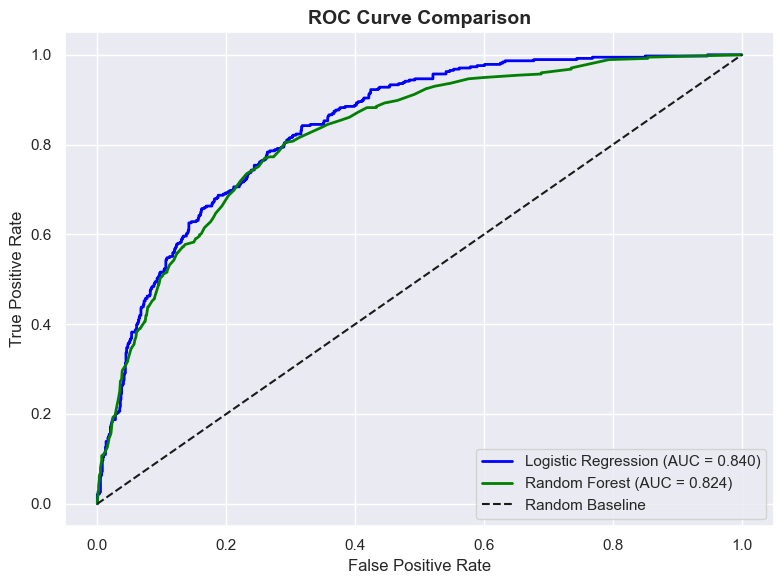

In [44]:
plt.figure(figsize=(8, 6))

for prob, name, color in [
    (lr_prob, 'Logistic Regression', 'blue'),
    (rf_prob, 'Random Forest', 'green')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

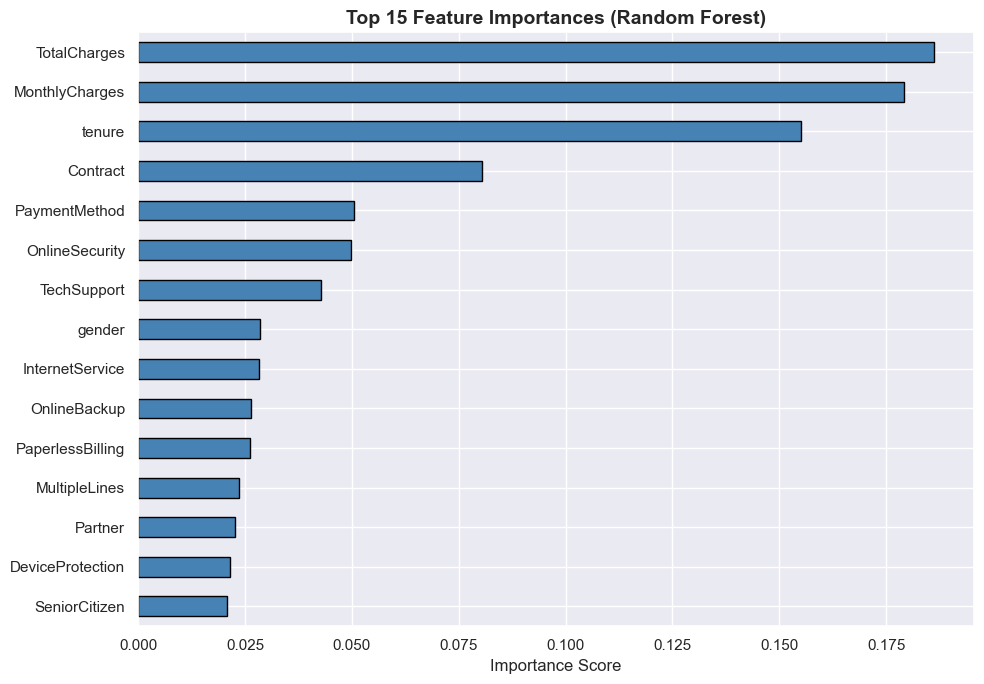

 Top features driving churn prediction:
TotalCharges      0.186240
MonthlyCharges    0.179079
tenure            0.155064
Contract          0.080442
PaymentMethod     0.050376
dtype: float64


In [45]:
feat_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_importance.tail(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(' Top features driving churn prediction:')
print(feat_importance.sort_values(ascending=False).head(5))

In [46]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_pred) * 100, 2),
        round(accuracy_score(y_test, rf_pred) * 100, 2)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_prob), 4),
        round(roc_auc_score(y_test, rf_prob), 4)
    ]
})

print('\nModel Comparison')
results


Model Comparison


,Model,Accuracy (%),ROC-AUC
0,Logistic Regression,79.84,0.8404
1,Random Forest,79.56,0.8237
